# Data preprocessing
- drop irrelevant columns like images
- drop rows with missing data
- preprocess text reviews
- analyze dataset

In [ ]:
!curl -sSL -o data/software.jsonl.gz https://mcauleylab.ucsd.edu/public_datasets/data/amazon_2023/raw/review_categories/Software.jsonl.gz

In [ ]:
!gunzip -f data/software.jsonl.gz

In [ ]:
import pandas as pd

df = pd.read_json("data/software.jsonl", lines=True)
df.head()

,rating,title,text,images,asin,parent_asin,user_id,timestamp,helpful_vote,verified_purchase
0,1,malware,mcaffee IS malware,[],B07BFS3G7P,B0BQSK9QCF,AGCI7FAH4GL5FI65HYLKWTMFZ2CQ,2019-07-03 19:37:12.076,0,False
1,5,Lots of Fun,I love playing tapped out because it is fun to...,[],B00CTQ6SIG,B00CTQ6SIG,AHSPLDNW5OOUK2PLH7GXLACFBZNQ,2015-02-16 20:58:56.000,0,True
2,5,Light Up The Dark,I love this flashlight app! It really illumin...,[],B0066WJLU6,B0066WJLU6,AHSPLDNW5OOUK2PLH7GXLACFBZNQ,2013-03-04 12:14:27.000,0,True
3,4,Fun game,One of my favorite games,[],B00KCYMAWK,B00KCYMAWK,AH6CATODIVPVUOJEWHRSRCSKAOHA,2019-06-20 20:10:28.662,0,True
4,4,I am not that good at it but my kids are,Cute game. I am not that good at it but my kid...,[],B00P1RK566,B00P1RK566,AEINY4XOINMMJCK5GZ3M6MMHBN6A,2014-12-11 00:19:56.000,0,True


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4880181 entries, 0 to 4880180
Data columns (total 10 columns):
 #   Column             Dtype         
---  ------             -----         
 0   rating             int64         
 1   title              object        
 2   text               object        
 3   images             object        
 4   asin               object        
 5   parent_asin        object        
 6   user_id            object        
 7   timestamp          datetime64[ns]
 8   helpful_vote       int64         
 9   verified_purchase  bool          
dtypes: bool(1), datetime64[ns](1), int64(2), object(6)
memory usage: 339.7+ MB


In [ ]:
df.describe()

,rating,timestamp,helpful_vote
count,4.880181e+06,4880181,4.880181e+06
mean,3.935087e+00,2016-08-11 20:56:15.320964864,4.921711e+00
min,1.000000e+00,1999-03-15 04:02:39,-1.000000e+00
25%,3.000000e+00,2014-09-03 01:27:03,0.000000e+00
50%,5.000000e+00,2016-03-19 18:49:49,0.000000e+00
75%,5.000000e+00,2018-08-15 19:51:14.231000064,2.000000e+00
max,5.000000e+00,2023-09-11 02:13:11.515000,1.026700e+04
std,1.451875e+00,NaN,3.516860e+01


In [ ]:
df.columns

Index(['rating', 'title', 'text', 'images', 'asin', 'parent_asin', 'user_id',
       'timestamp', 'helpful_vote', 'verified_purchase'],
      dtype='object')

In [ ]:
df.drop(columns=['images'], inplace=True)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4880181 entries, 0 to 4880180
Data columns (total 9 columns):
 #   Column             Dtype         
---  ------             -----         
 0   rating             int64         
 1   title              object        
 2   text               object        
 3   asin               object        
 4   parent_asin        object        
 5   user_id            object        
 6   timestamp          datetime64[ns]
 7   helpful_vote       int64         
 8   verified_purchase  bool          
dtypes: bool(1), datetime64[ns](1), int64(2), object(5)
memory usage: 302.5+ MB


In [ ]:
df.drop_duplicates(inplace=True)
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4829124 entries, 0 to 4880180
Data columns (total 9 columns):
 #   Column             Dtype         
---  ------             -----         
 0   rating             int64         
 1   title              object        
 2   text               object        
 3   asin               object        
 4   parent_asin        object        
 5   user_id            object        
 6   timestamp          datetime64[ns]
 7   helpful_vote       int64         
 8   verified_purchase  bool          
dtypes: bool(1), datetime64[ns](1), int64(2), object(5)
memory usage: 336.2+ MB


In [ ]:
df.dropna(inplace=True)
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4829124 entries, 0 to 4880180
Data columns (total 9 columns):
 #   Column             Dtype         
---  ------             -----         
 0   rating             int64         
 1   title              object        
 2   text               object        
 3   asin               object        
 4   parent_asin        object        
 5   user_id            object        
 6   timestamp          datetime64[ns]
 7   helpful_vote       int64         
 8   verified_purchase  bool          
dtypes: bool(1), datetime64[ns](1), int64(2), object(5)
memory usage: 336.2+ MB


In [ ]:
df.describe()

,rating,timestamp,helpful_vote
count,4.829124e+06,4829124,4.829124e+06
mean,3.934995e+00,2016-08-12 16:39:16.271572736,4.916508e+00
min,1.000000e+00,1999-03-15 04:02:39,-1.000000e+00
25%,3.000000e+00,2014-09-04 02:00:36.249999872,0.000000e+00
50%,5.000000e+00,2016-03-20 17:45:25.500000,0.000000e+00
75%,5.000000e+00,2018-08-16 23:32:32.821500160,2.000000e+00
max,5.000000e+00,2023-09-11 02:13:11.515000,1.026700e+04
std,1.451903e+00,NaN,3.507460e+01


In [ ]:
df.to_json("data/software-clean.jsonl")

In [ ]:
!ls -lh

total 3.3G
drwxr-xr-x 1 root root 4.0K Apr 16 13:28 sample_data
-rw-r--r-- 1 root root 1.5G May  7 11:48 software-clean.jsonl
-rw-r--r-- 1 root root 1.8G May  7 11:43 software.jsonl


In [ ]:
df.head(10)

,rating,title,text,asin,parent_asin,user_id,timestamp,helpful_vote,verified_purchase
0,1,malware,mcaffee IS malware,B07BFS3G7P,B0BQSK9QCF,AGCI7FAH4GL5FI65HYLKWTMFZ2CQ,2019-07-03 19:37:12.076,0,False
1,5,Lots of Fun,I love playing tapped out because it is fun to...,B00CTQ6SIG,B00CTQ6SIG,AHSPLDNW5OOUK2PLH7GXLACFBZNQ,2015-02-16 20:58:56.000,0,True
2,5,Light Up The Dark,I love this flashlight app! It really illumin...,B0066WJLU6,B0066WJLU6,AHSPLDNW5OOUK2PLH7GXLACFBZNQ,2013-03-04 12:14:27.000,0,True
3,4,Fun game,One of my favorite games,B00KCYMAWK,B00KCYMAWK,AH6CATODIVPVUOJEWHRSRCSKAOHA,2019-06-20 20:10:28.662,0,True
4,4,I am not that good at it but my kids are,Cute game. I am not that good at it but my kid...,B00P1RK566,B00P1RK566,AEINY4XOINMMJCK5GZ3M6MMHBN6A,2014-12-11 00:19:56.000,0,True
5,4,good game,"Made me think , variety of the puzzles kept it...",B00CWY76CC,B00CWY76CC,AEINY4XOINMMJCK5GZ3M6MMHBN6A,2013-07-28 06:53:07.000,0,True
6,5,My favorite showVoice my favorite show,See the voice anytime my My favorite show,B018IOV40E,B018IOV40E,AEJDETWITK2KGACH7FUBMY33PPSQ,2018-03-07 20:56:00.247,0,True
7,5,Great Antivirus product,Not sure what else can be said about Norton pr...,B00EZPXYP4,B00EZPXYP4,AFSKPY37N3C43SOI5IEXEK5JSIYA,2013-11-13 15:55:13.000,0,False
8,1,Fraught with too many problems,Save your money and purchase a good (i.e. Nort...,B002I7PGT8,B002I7PGT8,AFSKPY37N3C43SOI5IEXEK5JSIYA,2013-04-19 13:38:15.000,0,False
9,4,Norton Internet Security,I always use Norton as my PC security applicat...,B0040GFFGO,B005ZKC4FO,AFSKPY37N3C43SOI5IEXEK5JSIYA,2013-04-11 09:08:23.000,0,False


### Standardize Text Data

- convert the `title` and `text` columns to lowercase and remove punctuation to ensure consistency for future text analysis

In [ ]:
import re

def clean_text(text):
    if isinstance(text, str):
        text = text.lower()
        text = re.sub(r'[^a-z0-9\s]', '', text) # Remove punctuation
        return text
    return text

df['title'] = df['title'].apply(clean_text)
df['text'] = df['text'].apply(clean_text)

display(df[['title', 'text']].head())

,title,text
0,malware,mcaffee is malware
1,lots of fun,i love playing tapped out because it is fun to...
2,light up the dark,i love this flashlight app it really illumina...
3,fun game,one of my favorite games
4,i am not that good at it but my kids are,cute game i am not that good at it but my kids...


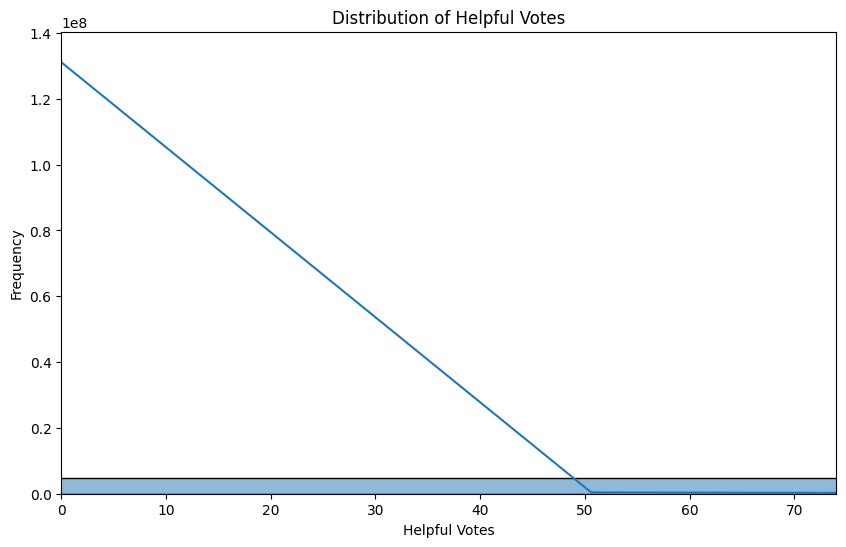

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.histplot(df['helpful_vote'], bins=50, kde=True)
plt.title('Distribution of Helpful Votes')
plt.xlabel('Helpful Votes')
plt.ylabel('Frequency')
plt.xlim(0, df['helpful_vote'].quantile(0.99))
plt.show()

The histogram shows a heavily skewed distribution for `helpful_vote`, with most values concentrated at the lower end and a very long tail of higher values. This indicates the presence of outliers.

For better analysis,  the `helpful_vote` column is capped at the 99th percentile to reduce the impact of extreme outliers.

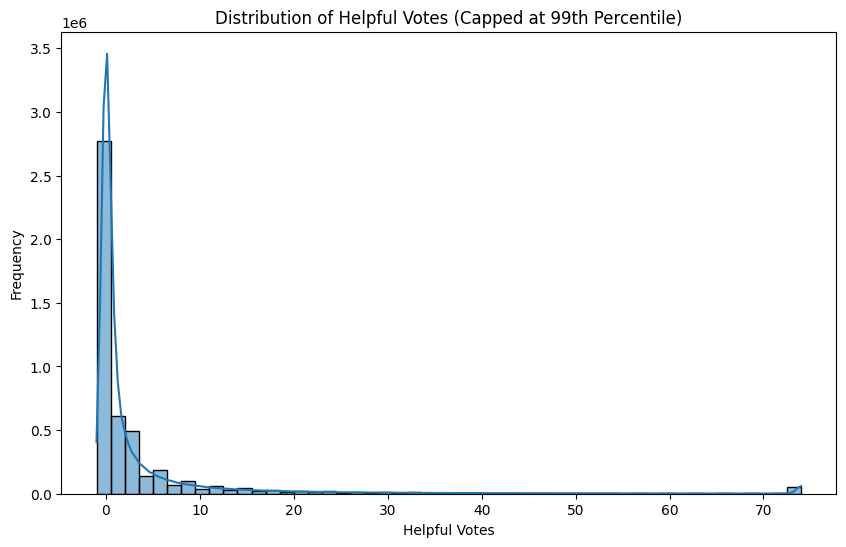

,helpful_vote
count,4.829124e+06
mean,3.716679e+00
std,1.050517e+01
min,-1.000000e+00
25%,0.000000e+00
50%,0.000000e+00
75%,2.000000e+00
max,7.400000e+01


In [ ]:
helpful_vote_cap = df['helpful_vote'].quantile(0.99)
df['helpful_vote'] = df['helpful_vote'].clip(upper=helpful_vote_cap)

plt.figure(figsize=(10, 6))
sns.histplot(df['helpful_vote'], bins=50, kde=True)
plt.title('Distribution of Helpful Votes (Capped at 99th Percentile)')
plt.xlabel('Helpful Votes')
plt.ylabel('Frequency')
plt.show()

display(df['helpful_vote'].describe())